# Customer Churn analysis

In [1]:
# import library 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading  Data set
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [8]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


In [9]:
df['gender']=df['gender'].map({'Male':1,'Female':0})

Text(0.5, 1.0, 'Correlation Heatmap')

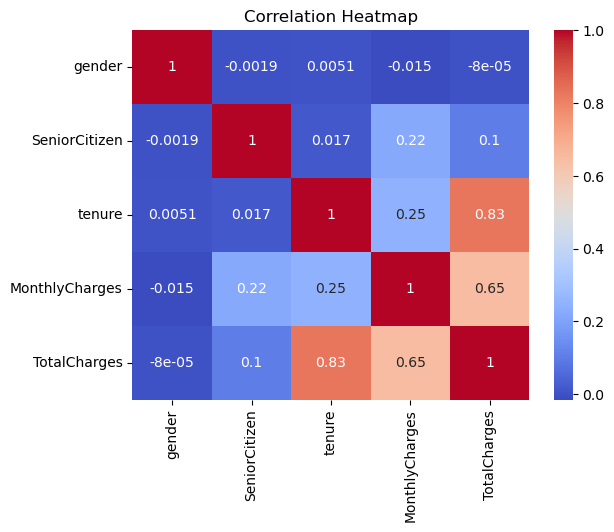

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC 
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.pipeline import Pipeline
label_encoder = LabelEncoder()  
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])



In [12]:
x = df.drop('Churn', axis=1)
y = df['Churn']

In [13]:
pipe=Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',RandomForestClassifier())
])
pipe2=Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',SVC())
])
pipe3=Pipeline([
    ('scaler',StandardScaler()),    
    ('classifier',LogisticRegression())
])
pipe4=Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',RandomForestClassifier(n_estimators=100))
])

pipe5=Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',AdaBoostClassifier(n_estimators=100))
])
pipe6=Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',GradientBoostingClassifier(n_estimators=100))
])
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [14]:
for model in [pipe, pipe2, pipe3, pipe4, pipe5, pipe6]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Model: {model.named_steps['classifier'].__class__.__name__}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Accuracy Score:", accuracy_score(y_test, y_pred))
    print("\n")

Model: RandomForestClassifier
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409

Confusion Matrix:
[[945  91]
 [193 180]]
Accuracy Score: 0.7984386089425124


Model: SVC
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.87      1036
           1       0.68      0.50      0.57       373

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

Confusion Matrix:
[[948  88]
 [187 186]]
Accuracy Score: 0.8048261178140526


Model: LogisticRegression
Classification Report:
              precision    recall  f1-score   support


In [15]:
from sklearn.ensemble import VotingClassifier
voting_clf = VotingClassifier(estimators=[
    ('rf', pipe),
    ('svc', pipe2),
    ('lr', pipe3),
    ('rf100', pipe4),
    ('adaboost', pipe5),
    ('gb', pipe6)
], voting='hard')
voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_test)
print("Voting Classifier Performance:")
print(classification_report(y_test, y_pred_voting))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_voting))
print("Accuracy Score:", accuracy_score(y_test, y_pred_voting))


Voting Classifier Performance:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      1036
           1       0.71      0.51      0.59       373

    accuracy                           0.82      1409
   macro avg       0.78      0.72      0.74      1409
weighted avg       0.81      0.82      0.80      1409

Confusion Matrix:
[[959  77]
 [183 190]]
Accuracy Score: 0.815471965933286


In [16]:
#model saving
import joblib
joblib.dump(voting_clf, 'customer_churn_model.pkl')

['customer_churn_model.pkl']

In [18]:
import pickle

pickle.dump(x.columns.tolist(), open("columns.pkl", "wb"))